In [80]:
# Enable autoreload of imported modules

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
# Compute normalized columns

def normalize_data_columns(df):
    columns = ["n_docs", "dist_smooth_to_prev_smooth", "dispersion", "curvature", "drift_from_baseline"]

    for col in columns:
        df[f"{col}_norm"] = df[col]/df[col].sum()
    
    return df

def normalize_data_columns_per_dataset(df):
    """
    Normalize data per dataset and per group.
    That is, makes column `c` (e.g.: n_docs) in dataset `d` (e.g.: helene) and group `g` (e.g.: event, background) sum to 1.
    """
    columns = ["n_docs", "dist_smooth_to_prev_smooth", "dispersion", "curvature", "drift_from_baseline"]

    cols_norm = [f"{col}_norm" for col in columns]

    df[cols_norm] = df.groupby(["event_name", "group"])[columns].transform(
        lambda x: x/x.sum()
    )
    return df





In [82]:
import pandas as pd
from pathlib import Path





data_id = "data"
datasets_dir = Path(f"{data_id}/")

output_dir = Path(f"results/")
output_dir.mkdir(exist_ok=True, parents=True)

drop_datasets = {'helene'}

datasets = [d.name for d in datasets_dir.iterdir() if d.is_dir() and d.name not in drop_datasets]

print(f"Datasets: {datasets}")

data = []  # Store dataset results from temporal analysis
xlim = (-7,30)  # Define plot limits


# Load event labels
with open("event_labels.csv") as fin:
    event_labels = {}
    for line in fin:
        event, label = line.strip().split(",",1)
        event_labels[event] = label

for dataset in datasets:
    data_dir = datasets_dir.joinpath(dataset)

    # Load daily files
    event_df = pd.read_csv(data_dir.joinpath("daily_event.csv"))
    bg_df = pd.read_csv(data_dir.joinpath("daily_background.csv"))
    overall_df = pd.read_csv(data_dir.joinpath("daily_overall.csv"))
    dfs = [overall_df, bg_df, event_df]  # Get all dfs
    
    event_df["group"] = "event"
    bg_df["group"] = "background"
    overall_df["group"] = "overall"
    event_df["event_type"] = event_labels[dataset]
    bg_df["event_type"] = event_labels[dataset]

    ds_df = pd.concat((overall_df, bg_df, event_df))
    ds_df["event_name"] = dataset
    ds_df["event_type"] = event_labels[dataset]
    data.append(ds_df)

df = pd.concat(data).reset_index(drop=True)
df = normalize_data_columns_per_dataset(df)

# Trim days
df = df[(df['day']>=xlim[0]) & (df['day']<=xlim[1])]

df.to_csv(output_dir.joinpath("temporal_results_all.csv"), index=None)


Datasets: ['tornadokentucky', 'socalfires', 'milton', 'montereypark', 'hawaiifires', 'boogaloo', 'firekansas', 'buffaloshooting', 'uvalde', 'elpaso', 'floodtx', 'virginiabeach', 'boulderfire']


In [83]:
import matplotlib.pyplot as plt

def plot_onset_line(ymin=-1, ymax=1, linestyles="-", colors="black", linewidth=1, label="Event onset", ax=None):
    if ax is None:
        plt.autoscale(False)  # Set autoscale before drawing vertical line
        plt.vlines((0), ymin=ymin, ymax=ymax, linestyles=linestyles, colors=colors, linewidths=linewidth, label=label)
    else:
        ax.axvline(x=0, linestyle=linestyles, color=colors, linewidth=linewidth, label=label)

In [84]:
cols = ['n_docs_norm', 'dist_smooth_to_prev_smooth_norm', 'dispersion_norm', 'dispersion'
        ]

In [85]:
import numpy as np


def get_temporal_parameters(df,
                            cols=None,
                            drop_event_types={'political'},
                            error="sem"):
    if cols is None:
        cols = ['n_docs_norm', 'dist_smooth_to_prev_smooth_norm', 'dispersion_norm',
                'drift_from_baseline', 'n_topics_active', 'weighted_mean_sim', 'weighted_mean_var',
                'similarity_policy_keywords', 'similarity_misinformation_keywords', 'similarity_hatespeech_keywords']
        
    event_types = sorted(df['event_type'].unique())
    window=5
    rows = list()
    for y_col in cols:
            for evt_t in event_types:
                if evt_t in drop_event_types:
                    continue
                df_t = df[(df['event_type']==evt_t)&(df['group']!='overall')]
                df_t = df_t.sort_values('dt')
                avg_dt = df_t.groupby(['group', 'dt'])[y_col].mean()
                std_dt = df_t.groupby(['group', 'dt'])[y_col].std()

                # Get values for each group
                y_bg = avg_dt.background.rolling(window=window, min_periods=1).mean()
                y_event = avg_dt.event.rolling(window=window, min_periods=1).mean()
                y_event = y_event[y_event.index >= 0]
                
                # Get baseline from background
                y_baseline = avg_dt.background.mean()
            
                # Find peak index and amplitude
                peak_idx = y_event.idxmax()
                amplitude = float(y_event[peak_idx]-y_baseline)

                # Compute half-life
                hl_target = y_baseline + amplitude / 2.0
                tail = y_event[y_event.index > peak_idx]
                cross_mask = tail <= hl_target
                if cross_mask.any():
                    hl_dt = tail.index[np.argmax(cross_mask.values)]
                
    
                x_cp = y_event[(y_event.index >= 0) & (y_event.index <= 30)]
                
                rows.append({
                     "signal": y_col,
                     "event_type": evt_t,
                     "baseline": y_baseline,
                     "peak_idx": peak_idx,
                     "peak_val": y_event[peak_idx],
                     "amplitude": amplitude,
                     "half_life_days": hl_dt,
                })
        
    return pd.DataFrame(rows)


results_temp = get_temporal_parameters(df, cols=cols)
results_temp.to_csv(output_dir.joinpath("temporal_parameters.csv"), index=None)
display(results_temp)

,signal,event_type,baseline,peak_idx,peak_val,amplitude,half_life_days
0,n_docs_norm,disaster,0.025764,5,0.079233,0.053470,9
1,n_docs_norm,violence,0.027247,5,0.096740,0.069494,8
2,dist_smooth_to_prev_smooth_norm,disaster,0.026125,4,0.104626,0.078501,7
3,dist_smooth_to_prev_smooth_norm,violence,0.026655,4,0.084427,0.057772,6
4,dispersion_norm,disaster,0.025397,5,0.052009,0.026612,10
5,dispersion_norm,violence,0.027214,5,0.067784,0.040570,8
6,dispersion,disaster,0.020545,5,0.038435,0.017890,10
7,dispersion,violence,0.015313,4,0.028888,0.013575,7


In [86]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_style("white")
sns.set_palette("Accent")
plt.rcParams['font.size'] = 20

from scipy.stats import sem
import numpy as np



def plot_event_background_timeseries(df, 
                                     cols=None,
                                     plot_style="line",
                                     plot_error=True,
                                     plot_bg=False,
                                     show_curve_labels=False,
                                     plot_changepoints=False,
                                     marker_points=None,
                                     x_label="t (days)",
                                     y_label=None,
                                     title=None,
                                     line_alpha=1,
                                     lw=5,
                                     window=5,
                                     leg_fontsize=16,
                                     savefig=True,
                                     plot_combined=False,
                                     plot_combined_bg=False,
                                     colors=None,
                                     drop_event_types={'political'},
                                     error="sem"):

    event_types = sorted([ev for ev in df['event_type'].unique() if ev not in {'political'}])
    x = np.array(sorted(df['dt'].unique()))

    if cols is None:
        cols = ['n_docs_norm', 'dist_smooth_to_prev_smooth_norm', 'dispersion_norm', 'dispersion',
                ]
        
    if colors is None:
        colors = sns.color_palette('deep')[:2]

    linestyles = ['-', '--']

    if plot_combined:
        fig_comb, ax_comb = plt.subplots()
        ax_comb.set_xlim(*xlim)
    
    bg_comb = {}

    for y_col in cols:
        for ev_i, evt_t in enumerate(event_types):
            if evt_t in drop_event_types:
                continue
            df_t = df[(df['event_type']==evt_t)&(df['group']!='overall')]
            df_t = df_t.sort_values('dt')
            avg_dt = df_t.groupby(['group', 'dt'])[y_col].mean()
            std_dt = df_t.groupby(['group', 'dt'])[y_col].std()

            # Get values for each group
            y_bg = avg_dt.background.rolling(window=window, min_periods=1).mean()
            y_event = avg_dt.event.rolling(window=window, min_periods=1).mean()
            
            if plot_changepoints:
                event_cps = [y_event[y_event.index>=0].idxmax()]

            if error == "std":
                bg_err = std_dt.background.rolling(window=window, min_periods=1).mean()
                event_err = std_dt.event.rolling(window=window, min_periods=1).mean()
            elif error == "sem":
                bg_err = 2*sem(y_bg, nan_policy="omit")  # Use standard error of mean
                event_err = 2*sem(y_event, nan_policy="omit")

            fig, ax = plt.subplots();
            ax.set_xlim(*xlim)

            if show_curve_labels:
                label_bg = "Baseline"
                label_event = "Event"
            else:
                label_bg = None
                label_event = None
            # Make plots
            if plot_style == "line":
                if plot_error:
                    if plot_bg:
                        ax.fill_between(x[:len(y_bg)], y_bg-bg_err, y_bg+bg_err, alpha=0.2)
                    ax.fill_between(x[:len(y_event)], y_event-event_err, y_event+event_err, alpha=0.2, color=colors[ev_i])
                if plot_bg:
                    ax.plot(x[:len(y_bg)], y_bg, label=label_bg, linewidth=lw, linestyle=(0, (3, 1, 1, 1, 1, 1)));
                ax.plot(x[:len(y_event)], y_event, label=label_event, linewidth=lw, color=colors[ev_i])

                if plot_combined:
                    ax_comb.fill_between(x[:len(y_event)], y_event-event_err, y_event+event_err, alpha=0.2, color=colors[ev_i])
                    ax_comb.plot(x[:len(y_event)], y_event, linewidth=lw, color=colors[ev_i], linestyle=linestyles[ev_i], label=evt_t.capitalize(), alpha=line_alpha)

                bg_comb['x'] = x[:len(y_bg)]
                bg_comb['y_bg'] = y_bg
                bg_comb['bg_err'] = bg_err

            else:
                print(f"ERROR: Invalid plot style {plot_style}")


            if plot_changepoints:
                for cp in event_cps:
                    print(cp, y_event[cp])
                    ax.axvline(cp, color="black", linestyle='--', linewidth=0.5, label="Peak")
                    # ax.vlines([cp], ymax=y_event[cp], linestyle='--', linewidth=0.5, label="Peak")
            if marker_points:
                ax.scatter(marker_points, y_event[marker_points], marker="o", color="black", zorder=2, label="Change points")
            
            ax.axvline(0, color='black', linewidth=1, label="Event onset")


            ax.set_title(title);
            ax.legend(fontsize=leg_fontsize);
            ax.set_xlabel(x_label)
            ax.set_ylabel(y_label if y_label is not None else y_col)
            fig.tight_layout()
            if savefig:
                fig.savefig(output_dir.joinpath(f"{y_col}_{evt_t}.pdf"));
    
    if plot_combined:
        if plot_combined_bg:
            ax_comb.plot(bg_comb['x'], bg_comb['y_bg'], label='Baseline', linewidth=lw, linestyle=':', color='black', zorder=0);
        if plot_changepoints:
            for cp in event_cps:
                print(cp, y_event[cp])
                ax_comb.axvline(cp, color="black", linestyle='--', linewidth=0.5, label="Peak")
        ax_comb.axvline(0, color='black', linewidth=1, label="Event onset")
        ax_comb.set_title(title);
        ax_comb.legend(fontsize=leg_fontsize);
        ax_comb.set_xlabel(x_label)
        ax_comb.set_ylabel(y_label if y_label is not None else y_col)
        fig_comb.tight_layout()
        fig_comb.savefig(output_dir.joinpath(f"{y_col}_comb.pdf"))

# plot_event_background_timeseries(df, cols=cols, plot_bg=False)

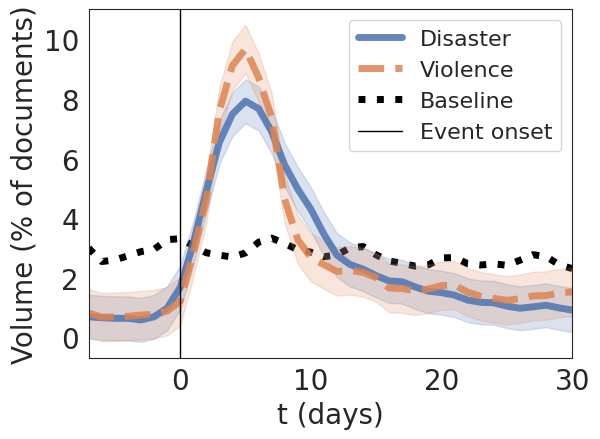

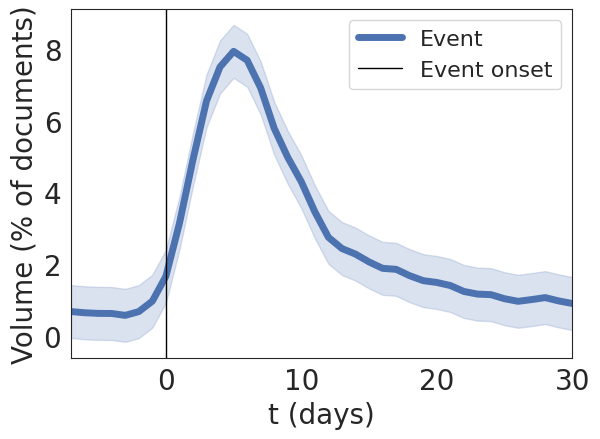

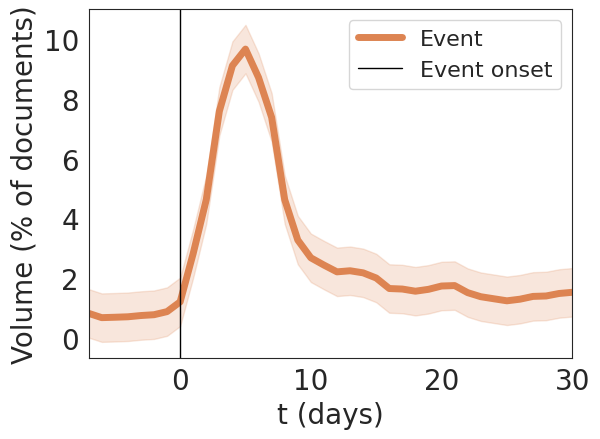

In [87]:
cols = ['n_docs_norm']
df['n_docs_norm'] *= 100
plot_event_background_timeseries(df, cols=cols, 
                                 plot_changepoints=False,
                                  plot_style="line", 
                                 y_label="Volume (% of documents)",
                                 title=None,
                                 line_alpha=0.85,
                                 show_curve_labels=True,
                                 plot_bg=False,
                                 plot_combined=True,
                                 plot_combined_bg=True
                                 )

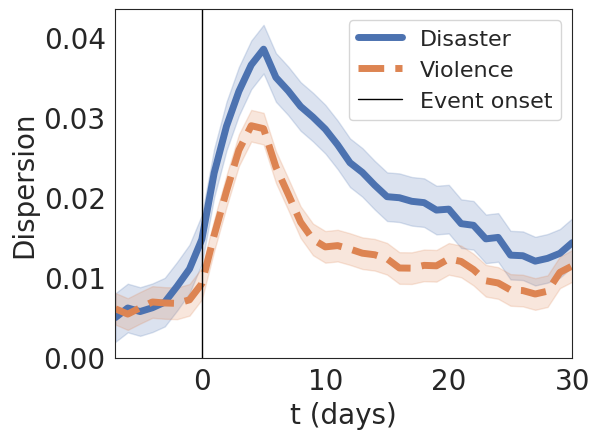

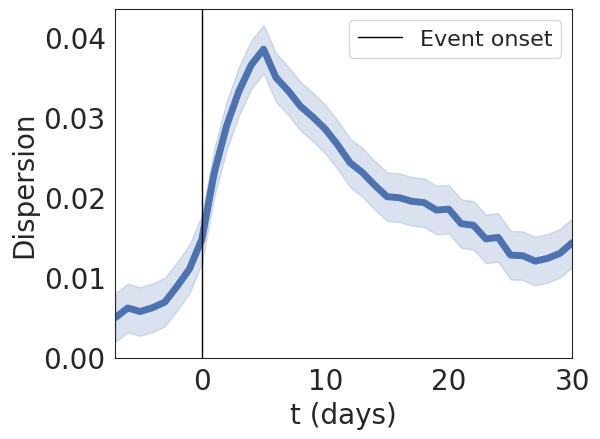

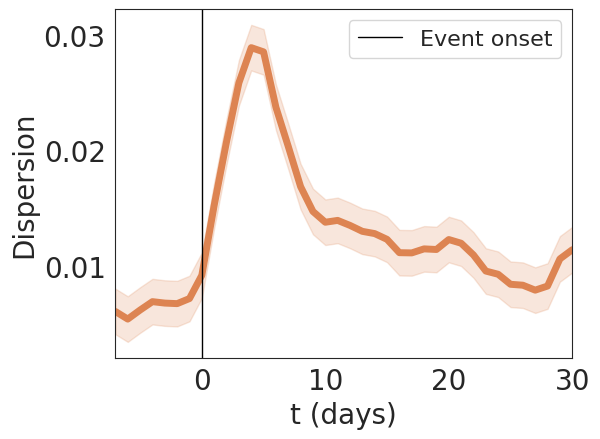

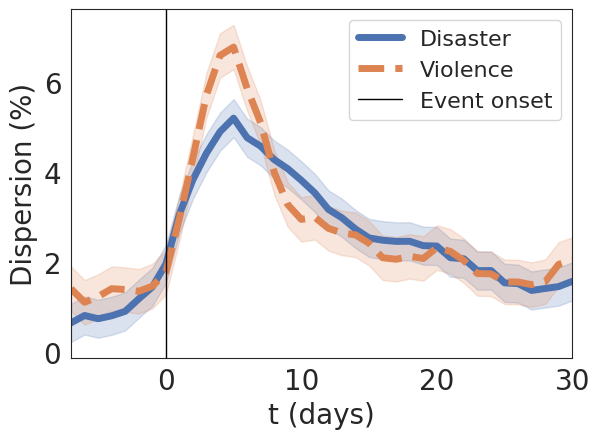

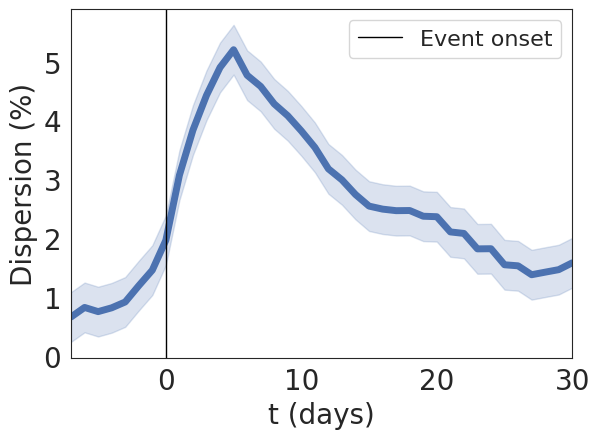

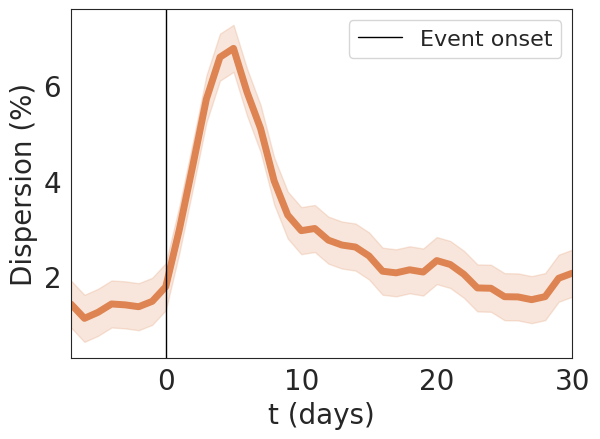

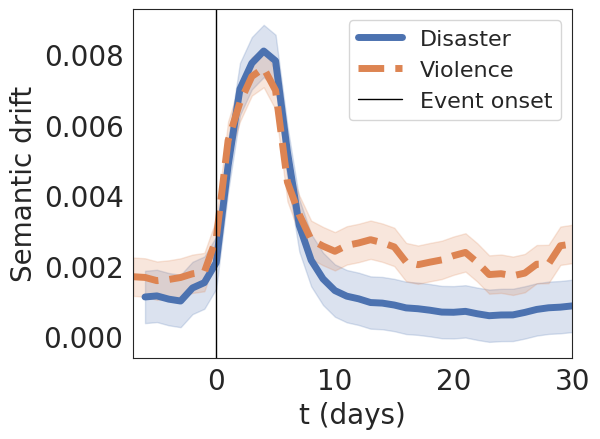

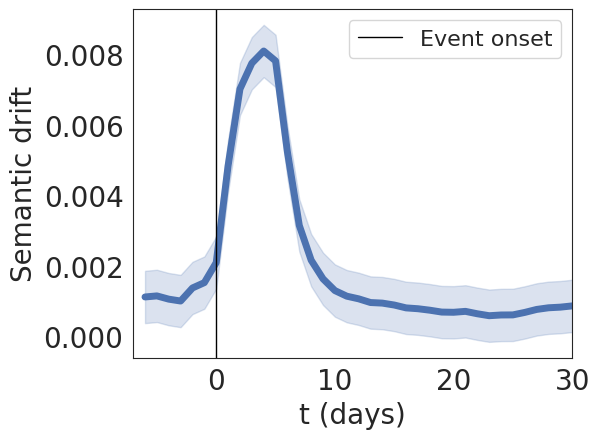

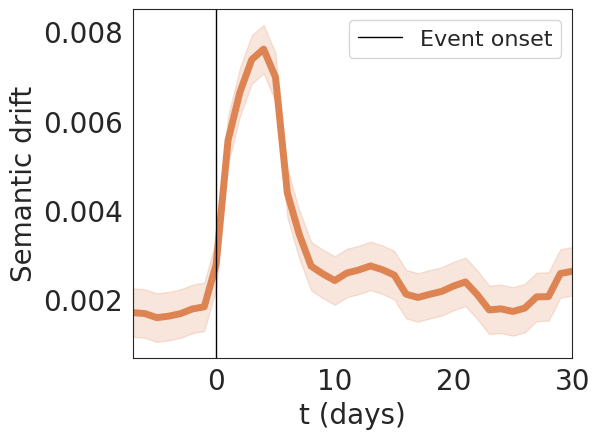

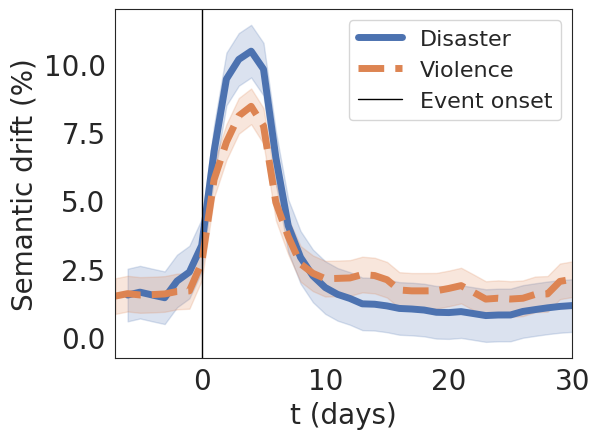

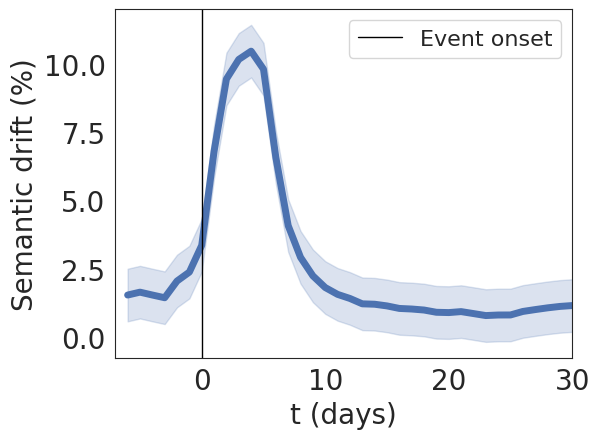

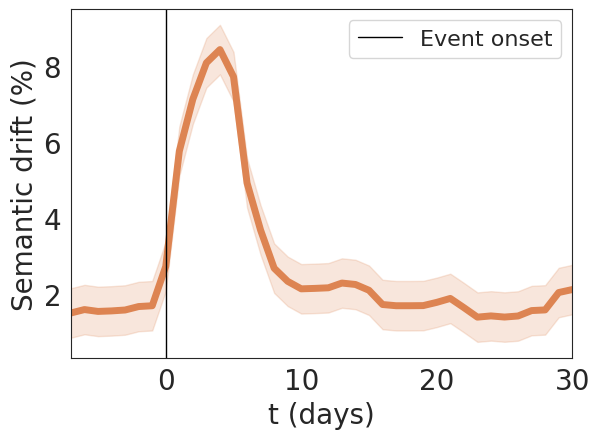

In [88]:
### Make plots without background

cols = ['dispersion', 'dispersion_norm', 'dist_smooth_to_prev_smooth', 'dist_smooth_to_prev_smooth_norm']
labels = ['Dispersion', 'Dispersion (%)', 'Semantic drift', 'Semantic drift (%)']

cols_norm = [c for c in cols if '_norm' in c]
df_ = df.copy()
df_[cols_norm] = df[cols_norm]*100

for col, lbl in zip(cols, labels):
    plot_event_background_timeseries(df_, cols= [col], plot_bg=False, y_label=lbl, plot_combined=True)